<a href="https://colab.research.google.com/github/LourdesBranchi/procesamiento-lenguaje-natural-1/blob/main/Desafio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.9 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [ ]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-06-20 19:39:06--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-06-20 19:39:06--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-06-20 19:39:06--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.

In [ ]:
# Posibles bandas
os.listdir("./songs_dataset/")

['dickinson.txt',
 'leonard-cohen.txt',
 'nicki-minaj.txt',
 'bruce-springsteen.txt',
 'missy-elliott.txt',
 'Kanye_West.txt',
 'beatles.txt',
 'dr-seuss.txt',
 'al-green.txt',
 'rihanna.txt',
 'eminem.txt',
 'nursery_rhymes.txt',
 'nirvana.txt',
 'alicia-keys.txt',
 'jimi-hendrix.txt',
 'bruno-mars.txt',
 'joni-mitchell.txt',
 'dj-khaled.txt',
 'r-kelly.txt',
 'disney.txt',
 'lorde.txt',
 'bob-marley.txt',
 'Lil_Wayne.txt',
 'johnny-cash.txt',
 'kanye-west.txt',
 'lil-wayne.txt',
 'notorious-big.txt',
 'dolly-parton.txt',
 'patti-smith.txt',
 'drake.txt',
 'blink-182.txt',
 'michael-jackson.txt',
 'radiohead.txt',
 'ludacris.txt',
 'amy-winehouse.txt',
 'adele.txt',
 'notorious_big.txt',
 'cake.txt',
 'kanye.txt',
 'lin-manuel-miranda.txt',
 'janisjoplin.txt',
 'britney-spears.txt',
 'lady-gaga.txt',
 'bjork.txt',
 'bob-dylan.txt',
 'prince.txt',
 'nickelback.txt',
 'paul-simon.txt',
 'bieber.txt']

In [ ]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_2032/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [ ]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [ ]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [ ]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# Creamos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [ ]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [ ]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [ ]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [ ]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [ ]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [ ]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [ ]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [ ]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [ ]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [ ]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

#### Datos
Se utilizarán tres colecciones de cuentos de Horacio Quiroga (Cuentos de Amor de Locura y de Muerte, Anaconda y Otros Cuentos, y Más Allá y Otros Cuentos), descargadas directamente desde textos.info.

In [ ]:
import requests
from bs4 import BeautifulSoup
import numpy as np

import multiprocessing
try:
    from gensim.models import Word2Vec
except:
    !pip install gensim
    from gensim.models import Word2Vec

from gensim.models.callbacks import CallbackAny2Vec

In [ ]:
def descargar_cuento(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")

    # Sacamos navegación, header y footer para quedarnos solo con el cuerpo del texto
    for tag in soup.find_all(["nav", "header", "footer", "script", "style"]):
        tag.decompose()

    parrafos = soup.find_all("p")
    return "\n".join(p.get_text(separator=" ", strip=True) for p in parrafos)


urls = [
    "https://www.textos.info/horacio-quiroga/cuentos-de-amor-de-locura-y-de-muerte/ebook",
    "https://www.textos.info/horacio-quiroga/anaconda-y-otros-cuentos/ebook",
    "https://www.textos.info/horacio-quiroga/mas-alla-y-otros-cuentos/ebook",
]

textos = []
for url in urls:
    texto = descargar_cuento(url)
    print(url, "->", len(texto), "caracteres")
    textos.append(texto)

corpus_crudo = "\n".join(textos)
print("\nTotal de caracteres en el corpus:", len(corpus_crudo))
print("\nPrimeros 500 caracteres:\n", corpus_crudo[:500])

https://www.textos.info/horacio-quiroga/cuentos-de-amor-de-locura-y-de-muerte/ebook -> 290463 caracteres
https://www.textos.info/horacio-quiroga/anaconda-y-otros-cuentos/ebook -> 305750 caracteres
https://www.textos.info/horacio-quiroga/mas-alla-y-otros-cuentos/ebook -> 200180 caracteres

Total de caracteres en el corpus: 796395

Primeros 500 caracteres:
 
Primavera
Era el martes de carnaval. Nébel acababa de entrar en el corso, ya al
oscurecer, y mientras deshacía un paquete de serpentinas, miró al
carruaje de delante. Extrañado de una cara que no había visto la tarde
anterior, preguntó a sus compañeros:
—¿Quién es? No parece fea.
—¡Un demonio! Es lindísima. Creo que sobrina, o cosa así, del doctor Arrizabalaga. Llegó ayer, me parece…
Nébel fijó entonces atentamente los ojos en la hermosa criatura. Era
una chica muy joven aún, acaso no más d


#### 1 - Preprocesamiento

Antes de entrenar el modelo, el texto crudo scrapeado de *textos.info* pasa por varias etapas de limpieza, pensadas para reducir el ruido típico de texto extraído de la web sin perder palabras con contenido real.

Primero se normalizan los saltos de línea y espacios no estándar (como `\r` o el espacio sin separación `\xa0` que suele quedar de HTML mal decodificado), y se separa el texto en oraciones usando el tokenizador de NLTK para español. Esto define que se considera "una oración" a los fines de la ventana de contexto de Word2Vec.

Cada oración se tokeniza en palabras con un filtro ampliado (que cubre también puntuación tipográfica como puntos suspensivos, comillas angulares y guiones largos, que el filtro por defecto de Keras no contempla), y luego se aplican tres filtros adicionales sobre cada token:

* Se **eliminan las stopwords del español** (artículos, preposiciones, conjunciones), tanto para mejorar la señal de co-ocurrencia entre palabras de contenido real, como porque `index_to_key` ordena el vocabulario por frecuencia y las stopwords más comunes terminarían dominando el gráfico de TSNE, tapando los grupos temáticos interesantes.

* Se **descartan los tokens que no son puramente alfabéticos** (`isalpha()`), lo que saca de un solo golpe números, signos de puntuación residuales y cualquier carácter raro que se haya colado en el scraping, sin necesidad de enumerar uno por uno todos los casos posibles.

* Se **descartan los tokens de una sola letra**, que en este corpus resultaron ser en su mayoría fragmentos de palabras cortadas por guionado al final de línea en el texto original, sin contenido semántico propio. El umbral se mantiene en una sola letra (y no más) para no perder palabras españolas válidas de dos letras, como "ir" o "fe".

Esta limpieza no elimina el 100% del ruido residual, scrapear texto de la web nunca da un resultado perfecto, pero reduce la proporción de artefactos a un nivel que no debería afectar de forma significativa la interpretación de los resultados.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from tensorflow.keras.preprocessing.text import text_to_word_sequence

oraciones = sent_tokenize(corpus_crudo, language="spanish")
print("Cantidad de oraciones:", len(oraciones))

stop_words = set(stopwords.words('spanish'))
sentence_tokens = []
for oracion in oraciones:
    tokens = text_to_word_sequence(oracion)
    tokens_filtrados = [t for t in tokens if t.isalpha() and len(t) > 1 and t not in stop_words]
    sentence_tokens.append(tokens_filtrados)

print("Cantidad de oraciones:", len(sentence_tokens))
sentence_tokens[:2]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cantidad de oraciones: 9809
Cantidad de oraciones: 9809


[['primavera', 'martes', 'carnaval'],
 ['nébel',
  'acababa',
  'entrar',
  'corso',
  'oscurecer',
  'mientras',
  'deshacía',
  'paquete',
  'serpentinas',
  'miró',
  'carruaje',
  'delante']]

#### 2 - Crear los vectores (word2vec)

In [ ]:
class callback(CallbackAny2Vec):
    """Callback para imprimir el loss después de cada época"""
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss - self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss


w2v_model = Word2Vec(
    min_count=3,    # bajamos el piso respecto al ejemplo de clase (corpus más chico)
    window=5,
    vector_size=200,
    negative=20,
    workers=1,
    sg=1            # skip-gram
)

w2v_model.build_vocab(sentence_tokens)
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de palabras distintas en el vocabulario:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 9809
Cantidad de palabras distintas en el vocabulario: 4433


#### 3 - Entrenar embeddings

In [ ]:
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=20,
    compute_loss=True,
    callbacks=[callback()]
)

Loss after epoch 0: 1304680.375
Loss after epoch 1: 695946.125
Loss after epoch 2: 606538.25
Loss after epoch 3: 593059.25
Loss after epoch 4: 591960.75
Loss after epoch 5: 583181.25
Loss after epoch 6: 563888.0
Loss after epoch 7: 561767.5
Loss after epoch 8: 561175.0
Loss after epoch 9: 557455.5
Loss after epoch 10: 553427.0
Loss after epoch 11: 549378.5
Loss after epoch 12: 544793.0
Loss after epoch 13: 535545.5
Loss after epoch 14: 530587.0
Loss after epoch 15: 528104.0
Loss after epoch 16: 524833.0
Loss after epoch 17: 522671.0
Loss after epoch 18: 523893.0
Loss after epoch 19: 519448.0


(1001776, 1282320)

#### 4 - Ensayar
Búsqueda de términos más similares y menos similares a palabras de interés del corpus.

In [ ]:
# Primero date una idea de qué palabras hay disponibles:
print(w2v_model.wv.index_to_key[:50])

['usted', 'ojos', 'si', 'dos', 'vez', 'bien', 'hombre', 'día', 'fin', 'noche', 'aún', 'mujer', 'después', 'siempre', 'ahora', 'casa', 'vida', 'entonces', 'mismo', 'así', 'pues', 'tres', 'cabeza', 'amor', 'tiempo', 'aquí', 'ser', 'días', 'momento', 'años', 'nuevo', 'mientras', 'toda', 'voz', 'cosa', 'instante', 'mañana', 'veces', 'menos', 'bajo', 'tarde', 'todas', 'allá', 'puede', 'mano', 'tras', 'hacer', 'tan', 'tal', 'ver']


In [ ]:
terminos = ["selva", "muerte", "amor", "monte", "noche"]

for termino in terminos:
    if termino in w2v_model.wv:
        print(f"\nMás similares a '{termino}':")
        for palabra, score in w2v_model.wv.most_similar(termino, topn=5):
            print(f"  {palabra}: {score:.3f}")
    else:
        print(f"\n'{termino}' no está en el vocabulario, probá con otra.")


Más similares a 'selva':
  ras: 0.955
  artefacto: 0.951
  piedras: 0.950
  coral: 0.947
  arrugas: 0.945

Más similares a 'muerte':
  pabellón: 0.846
  desgracia: 0.826
  ansia: 0.819
  posibilidad: 0.810
  mismas: 0.810

Más similares a 'amor':
  propio: 0.710
  hijo: 0.660
  diablo: 0.655
  encanto: 0.653
  dicha: 0.645

Más similares a 'monte':
  punta: 0.748
  campo: 0.741
  vera: 0.736
  negro: 0.726
  rancho: 0.719

Más similares a 'noche':
  última: 0.722
  siguiente: 0.711
  recibí: 0.695
  baile: 0.693
  riacho: 0.688


Los resultados de `most_similar` muestran distintos niveles de coherencia semántica según el término consultado, lo cual también es información valiosa sobre las limitaciones del modelo entrenado con un corpus de este tamaño.

**"monte"** es el caso más claro: sus vecinos más cercanos son "campo", "vera", "rancho" y "punta", todo vocabulario rural/geográfico consistente con el entorno narrativo del dataset.

**"muerte"** y **"amor"** muestran resultados mixtos: junto a palabras claramente temáticas ("desgracia" y "ansia" para muerte; "encanto" y "dicha" para amor) aparecen también vecinos más genéricos o gramaticales ("mismas", "posibilidad") que no aportan demasiado a la interpretación. Esto es esperable: no todas las palabras del entorno cercano de un término van a ser semánticamente reveladoras, sobre todo con un corpus de este tamaño.

**"noche"** combina dos tipos de vecinos: por un lado, palabras que comparten el mismo rol gramatical de modificar temporalmente a "noche" ("última", "siguiente"); por otro, palabras más temáticas como "baile" y "riacho", consistentes con escenas nocturnas de los cuentos.

**"selva"** es el término con los vecinos menos interpretables ("ras", "artefacto", "piedras", "coral", "arrugas"), incluso después del preprocesamiento del corpus. Con un volumen de texto relativamente chico, las similitudes directas para ciertas palabras pueden no captar relaciones semánticas claras.

In [ ]:
terminos = ["selva", "muerte", "amor", "monte", "noche"]

for termino in terminos:
    if termino in w2v_model.wv:
        print(f"\nMenos similares a '{termino}':")
        for palabra, score in w2v_model.wv.most_similar(negative=[termino], topn=5):
            print(f"  {palabra}: {score:.3f}")
    else:
        print(f"\n'{termino}' no está en el vocabulario, probá con otra.")


Menos similares a 'selva':
  maría: -0.310
  día: -0.326
  momento: -0.347
  mañana: -0.359
  cosa: -0.377

Menos similares a 'muerte':
  día: -0.122
  mañana: -0.154
  años: -0.185
  siguiente: -0.186
  bajo: -0.195

Menos similares a 'amor':
  chacra: -0.085
  camino: -0.085
  dos: -0.097
  peón: -0.101
  media: -0.103

Menos similares a 'monte':
  años: -0.087
  menos: -0.114
  días: -0.114
  mano: -0.115
  grant: -0.116

Menos similares a 'noche':
  víboras: 0.018
  real: -0.160
  todas: -0.165
  grandes: -0.177
  haber: -0.181


A diferencia de los resultados de `most_similar` directo, acá los scores son más débiles (entre -0.4 y 0.02, frente a valores de 0.6-0.9 en los términos más similares), lo cual ya es un dato interesante en sí mismo: el modelo no encontró "opuestos" tan claros como sí encontró "parecidos".

Esto tiene una explicación: los antónimos reales suelen aparecer en contextos muy parecidos en el texto (por ejemplo, "vida" y "muerte", o "amor" y "odio", muchas veces se mencionan juntos en la misma oración o párrafo), así que un modelo que aprende solo de coocurrencia, como Word2Vec, tiene dificultad estructural para separarlos, y termina poniéndolos relativamente cerca en vez de lejos. Por eso era esperable que esta parte diera resultados menos interpretables.

Hay, sin embargo, un patrón que se repite: palabras temporales genéricas como "día", "mañana", "momento", "años", "haber" y "siguiente" aparecen una y otra vez como las "menos similares". Esto sugiere que lo que está capturando el modelo no es una oposición semántica específica a cada palabra, sino que estas palabras genéricas de tiempo simplemente ocupan una región del espacio bastante alejada del vocabulario "concreto" del corpus (selva, muerte, monte), probablemente por ser palabras de uso muy frecuente y disperso en cualquier tipo de oración.

#### 5 - Tests de analogías

In [ ]:
def test_analogia(positivos, negativos, topn=5):
    todas = positivos + negativos
    faltantes = [p for p in todas if p not in w2v_model.wv]
    if faltantes:
        print("No están en el vocabulario:", faltantes)
        return
    resultado = w2v_model.wv.most_similar(positive=positivos, negative=negativos, topn=topn)
    print(f"{' + '.join(positivos)} - {' - '.join(negativos)} ≈")
    for palabra, score in resultado:
        print(f"  {palabra}: {score:.3f}")

test_analogia(positivos=["perro", "selva"], negativos=["casa"])

perro + selva - casa ≈
  negro: 0.779
  animal: 0.708
  hundió: 0.707
  culebra: 0.706
  yarará: 0.705


In [ ]:
w2v_model.wv.most_similar("perro", topn=10)

[('rabioso', 0.7626197338104248),
 ('aullido', 0.7566887736320496),
 ('negro', 0.7315179705619812),
 ('vuelta', 0.7301936745643616),
 ('animal', 0.7293141484260559),
 ('pescuezo', 0.7179914712905884),
 ('rabia', 0.7006086707115173),
 ('hocico', 0.6990097761154175),
 ('ladridos', 0.6956740617752075),
 ('avanzar', 0.6917344331741333)]

Al probar *"perro + selva − casa"*, el modelo devuelve **"negro"**, **"animal"**, **"hundió"**, **"culebra"** y **"yarará"**. Sin embargo, al comparar contra los vecinos de **"perro"** en soledad (sin selva ni casa), se observa que **"negro"** y **"animal"** ya aparecían entre sus diez palabras más cercanas. Esto sugiere que estas dos palabras están más asociadas directamente a **"perro"** que a la relación selva/casa que se buscaba capturar con la analogía.

En cambio, **"culebra"** y **"yarará"** no figuran entre los vecinos de **"perro"** solo, lo que indica que sí emergieron genuinamente de la operación vectorial completa. Esto tiene sentido: ambas son serpientes típicas de la selva, en contraposición al ámbito doméstico representado por **"perro"** y **"casa"**.

#### 6 - Reducción de dimensionalidad y visualización

In [ ]:
from sklearn.manifold import TSNE
import plotly.express as px

def reduce_dimensions(model, num_dimensions=2):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)
    return vectors, labels

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 200  # ajustalo según cuántas palabras tenga tu vocabulario y qué tan legible quede
fig = px.scatter(x=vecs[:MAX_WORDS, 0], y=vecs[:MAX_WORDS, 1], text=labels[:MAX_WORDS])
fig.show(renderer="colab")

Al inspeccionar la proyección en 2D generada con TSNE se identifican grupos de palabras que el modelo agrupó sin ninguna supervisión externa, simplemente a partir de los patrones de co-ocurrencia en el corpus.

Uno de los grupos más claros está formado por los números cardinales "tres", "cuatro", "cinco" y "diez", junto a las palabras "días" y "horas":
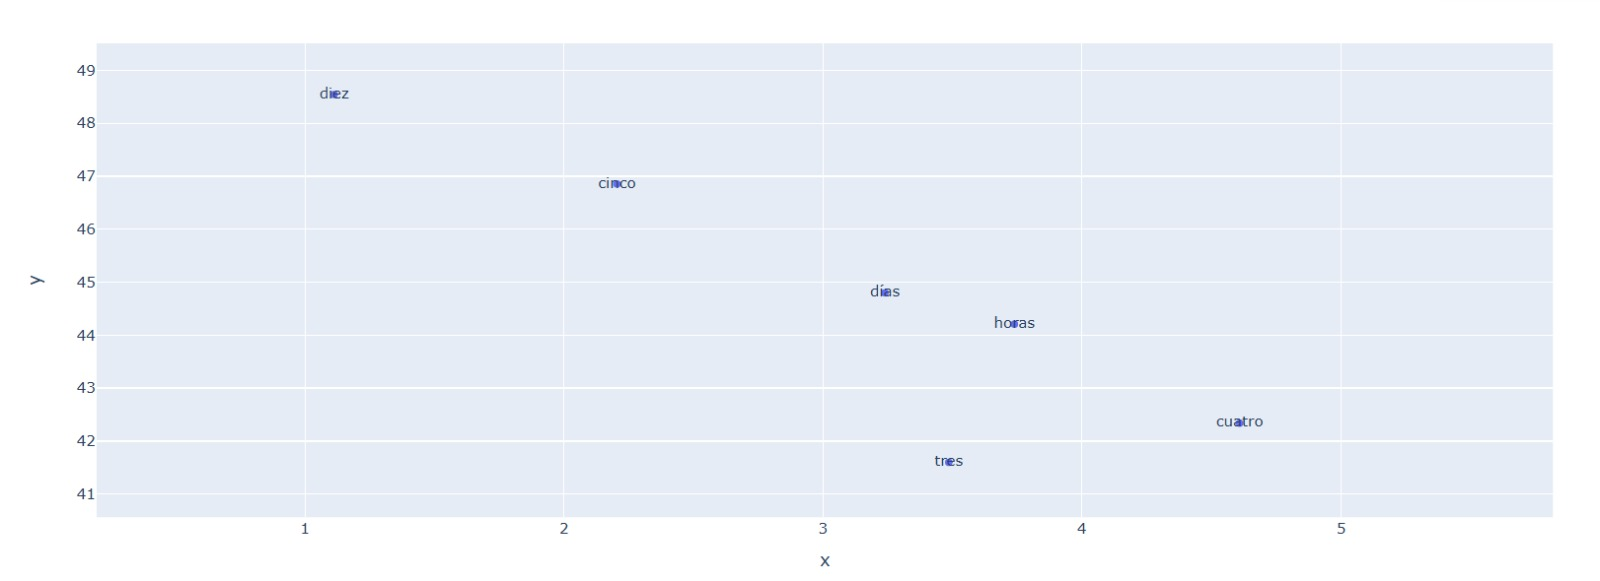
Este agrupamiento no responde a una similitud temática (los números no comparten un "significado" entre sí), sino a una similitud distribucional: en la narrativa de Quiroga el paso del tiempo se describe constantemente con construcciones del tipo "pasaron tres días" o "esperó cuatro horas", por lo que estas palabras aparecen una y otra vez en contextos casi idénticos. Esto demuestra que Word2Vec, basado en la hipótesis distributiva, no solo agrupa palabras por su contenido semántico (como ocurrió con el grupo de animales de la selva detectado en los tests de analogía), sino también por similitud puramente sintáctica o funcional: palabras que cumplen el mismo rol gramatical dentro de las oraciones

Otro grupo bien definido está formado por vocabulario de partes del cuerpo: "mano", "cara", "cabeza", "ojos", "manos", "brazos", "cuerpo" y "boca". A su alrededor aparecen palabras que funcionan como vecinas habituales de este campo semántico en cuentos: "mesa" y "cama" (objetos físicos asociados a la postura o el reposo del cuerpo) e "inmóvil" y "lado" (estado y posición física).

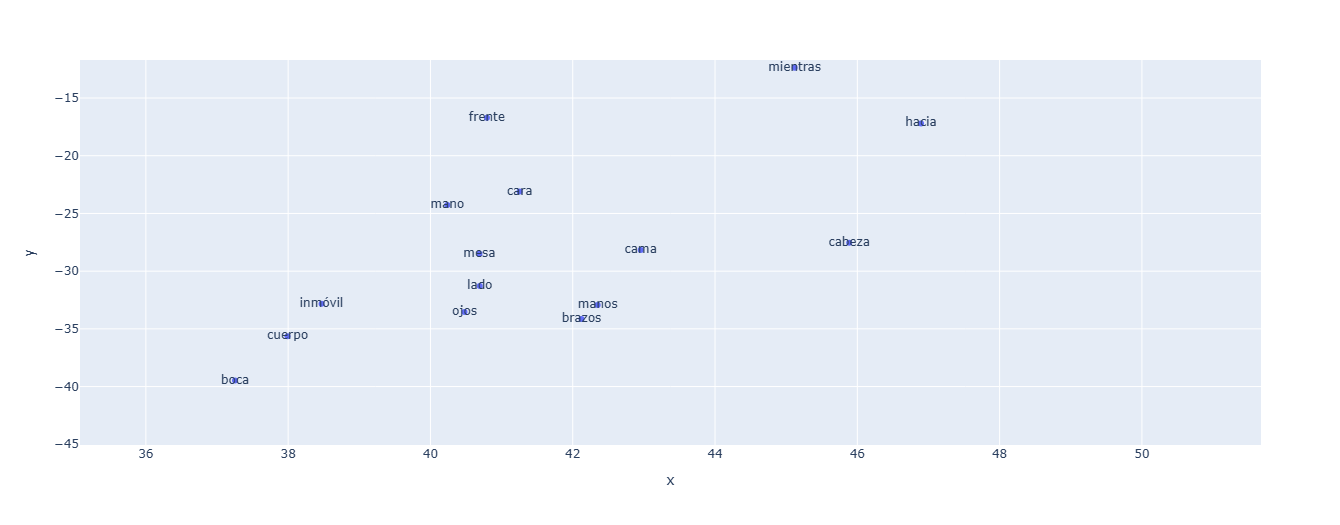

Un detalle interesante es la posición de la palabra "frente", que queda a mitad de camino entre este grupo y palabras como "hacia" y "mientras". Esto se explica por la ambigüedad de la palabra en español: puede ser "frente" como parte del cuerpo (sustantivo) o como preposición ("frente a", en sentido espacial). Como Word2Vec asigna un único vector fijo por palabra sin distinguir el sentido en que se usó cada vez, ese vector termina siendo un promedio entre ambos usos, lo cual explica su posición intermedia en el gráfico. Esta es justamente la limitación de los embeddings estáticos que los modelos basados en transformers (como BERT, por ejemplo) vinieron a resolver, calculando un embedding distinto para cada palabra según el contexto específico en el que aparece.